In [286]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn


## Preprocessing and EDA

In [287]:
df1= pd.read_excel(r'C:\Users\Mohamed Amr\Desktop\Sumerge AI internship\Safer Payments ML case 2 Data Set\Data Sets excel\core_banking_data_modified.xlsx')
df2= pd.read_excel(r'C:\Users\Mohamed Amr\Desktop\Sumerge AI internship\Safer Payments ML case 2 Data Set\Data Sets excel\customer_360_data_modified.xlsx')

In [288]:
df1


,CustomerID,AccountNumber,TransactionDate,TransactionAmount,TransactionType,AccountBalance,SPIntercept,SPTimestamp,LoginDevice,TransactionDevice,LoginTimestamp
0,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB30SPXD57546556446883,2020-11-02,8790.43,Online Payment,176954.23,0,2020-11-02 02:59:33,Laptop,Laptop,2020-11-02 02:59:30
1,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB66VKDN90953436305137,2020-12-17,7158.76,ATM Withdrawal,159414.04,1,2020-12-17 02:47:20,Laptop,Desktop,2020-12-17 02:46:31
2,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB31JMIV58178326185913,2022-09-16,61284.18,Money Transfer,998831.12,0,2022-09-16 12:28:49,Desktop,Desktop,2022-09-16 12:28:30
3,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB41JFJR59711046606283,2022-03-15,8244.07,Money Transfer,297781.36,0,2022-03-15 19:09:49,Tablet,Tablet,2022-03-15 19:09:35
4,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB89MWWC02062566820289,2020-09-26,1221.55,Online Payment,791467.34,0,2020-09-26 12:31:52,Mobile,Mobile,2020-09-26 12:31:41
...,...,...,...,...,...,...,...,...,...,...,...
49995,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB93WSLH63399166355899,2022-08-19,8169.44,ATM Withdrawal,437970.50,0,2022-08-19 19:07:43,Mobile,Mobile,2022-08-19 19:07:23
49996,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB52YAXA18297356502547,2020-02-20,80673.47,Online Payment,9824.86,0,2020-02-20 02:09:14,Laptop,Laptop,2020-02-20 02:09:00
49997,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB39EWTC90710675739428,2022-09-14,3370.36,ATM Withdrawal,536494.57,0,2022-09-14 23:36:41,Laptop,Laptop,2022-09-14 23:36:34
49998,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB74IOTY57465382870403,2022-06-12,21540.62,Online Payment,810778.90,1,2022-06-12 13:13:17,Tablet,Tablet,2022-06-12 13:12:58


In [289]:
df2

,CustomerID,CustomerName,Email,PhoneNumber,Address,DateOfBirth,Gender
0,e0497be9-6494-4efb-b575-fe9f55fccfe4,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",1972-09-15,Male
1,112d81e0-caca-4ba3-b6ad-c31178438dac,Emily Rodriguez,allison37@example.com,8103991750,"766 Smith Pines\nMatthewland, GU 69433",2014-01-20,Male
2,ec75eb51-73ea-40a9-b865-872adf4cc66e,Valerie Erickson,deleonmary@example.net,001-518-215-9510x63655,"064 Miller Canyon\nNew Nicole, MS 14275",1959-11-04,Female
3,8b8ddb5d-2b0a-434c-a25d-b4408dffb66c,Paige Riggs,courtney78@example.net,640-816-6789,USNS Ross\nFPO AA 94265,1940-10-14,Female
4,009cbfcb-ee30-40fd-88ac-eab5e3e6ff62,Devon Wright,camachodaniel@example.com,001-402-236-4082x438,"799 William Stream Apt. 755\nGarnertown, MS 89065",1967-01-22,Male
...,...,...,...,...,...,...,...
9995,95ca5d6e-f191-49a1-9375-1fa3564cd1c9,Donna Jones,robert92@example.net,(372)675-2067,2806 Robert Knoll Suite 901\nNorth Toddborough...,2004-10-01,Female
9996,4f1e7c02-6ea9-431b-bac3-18165fcf706e,Brandon Castillo,jenniferjohnson@example.org,951-433-5371x3977,"20220 Thomas Walks Suite 452\nJacobport, MH 47614",1966-03-21,Female
9997,dd3b4013-b4ab-4876-a963-efbd308ffffc,Elizabeth Black,jacob94@example.org,(352)336-6625,"54627 Rodriguez Haven Apt. 458\nLovefurt, UT 7...",1944-08-29,Female
9998,7db9b564-678f-4acf-bb3b-c23829be84ea,Levi Flores,amber90@example.com,(855)880-5728x5549,"076 Kimberly Cape Suite 218\nAlexanderport, MT...",1913-08-21,Male


In [290]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CustomerID         50000 non-null  object        
 1   AccountNumber      50000 non-null  object        
 2   TransactionDate    50000 non-null  datetime64[ns]
 3   TransactionAmount  49401 non-null  float64       
 4   TransactionType    50000 non-null  object        
 5   AccountBalance     49402 non-null  float64       
 6   SPIntercept        50000 non-null  int64         
 7   SPTimestamp        50000 non-null  datetime64[ns]
 8   LoginDevice        49700 non-null  object        
 9   TransactionDevice  49700 non-null  object        
 10  LoginTimestamp     50000 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(1), object(5)
memory usage: 4.2+ MB


In [291]:
df1.describe()

,TransactionDate,TransactionAmount,AccountBalance,SPIntercept,SPTimestamp,LoginTimestamp
count,50000,49401.000000,49402.000000,50000.000000,50000,50000
mean,2022-04-16 16:08:17.088000,18739.995012,499237.698734,0.236960,2022-04-17 04:11:30.049219840,2022-04-17 04:11:12.015379968
min,2020-01-01 00:00:00,10.100000,28.220000,0.000000,2020-01-01 00:50:01,2020-01-01 00:49:58
25%,2021-02-21 00:00:00,3466.710000,247981.172500,0.000000,2021-02-21 22:56:21.249999872,2021-02-21 22:55:42.249999872
50%,2022-04-17 00:00:00,6930.430000,497791.575000,0.000000,2022-04-17 09:31:27.500000,2022-04-17 09:31:14.500000
75%,2023-06-08 00:00:00,17857.120000,750850.082500,0.000000,2023-06-08 06:38:01.249999872,2023-06-08 06:37:58.249999872
max,2024-07-23 00:00:00,99990.590000,999984.310000,1.000000,2024-07-23 20:56:59,2024-07-23 20:56:41
std,NaN,26234.418145,289260.809963,0.425222,NaN,NaN


In [292]:
df1.head()


,CustomerID,AccountNumber,TransactionDate,TransactionAmount,TransactionType,AccountBalance,SPIntercept,SPTimestamp,LoginDevice,TransactionDevice,LoginTimestamp
0,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB30SPXD57546556446883,2020-11-02,8790.43,Online Payment,176954.23,0,2020-11-02 02:59:33,Laptop,Laptop,2020-11-02 02:59:30
1,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB66VKDN90953436305137,2020-12-17,7158.76,ATM Withdrawal,159414.04,1,2020-12-17 02:47:20,Laptop,Desktop,2020-12-17 02:46:31
2,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB31JMIV58178326185913,2022-09-16,61284.18,Money Transfer,998831.12,0,2022-09-16 12:28:49,Desktop,Desktop,2022-09-16 12:28:30
3,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB41JFJR59711046606283,2022-03-15,8244.07,Money Transfer,297781.36,0,2022-03-15 19:09:49,Tablet,Tablet,2022-03-15 19:09:35
4,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB89MWWC02062566820289,2020-09-26,1221.55,Online Payment,791467.34,0,2020-09-26 12:31:52,Mobile,Mobile,2020-09-26 12:31:41


In [293]:
df1.columns

Index(['CustomerID', 'AccountNumber', 'TransactionDate', 'TransactionAmount',
       'TransactionType', 'AccountBalance', 'SPIntercept', 'SPTimestamp',
       'LoginDevice', 'TransactionDevice', 'LoginTimestamp'],
      dtype='object')

In [294]:
# Missing data and it is percentage 

missing_data=pd.DataFrame({'total_missing': df1.isnull().sum(),
                           'perc_missing': (df1.isnull().sum()/10000)*100})
missing_data

,total_missing,perc_missing
CustomerID,0,0.00
AccountNumber,0,0.00
TransactionDate,0,0.00
TransactionAmount,599,5.99
TransactionType,0,0.00
AccountBalance,598,5.98
SPIntercept,0,0.00
SPTimestamp,0,0.00
LoginDevice,300,3.00
TransactionDevice,300,3.00


In [295]:
df1=df1.dropna()

In [296]:
df1.isnull().sum()

CustomerID           0
AccountNumber        0
TransactionDate      0
TransactionAmount    0
TransactionType      0
AccountBalance       0
SPIntercept          0
SPTimestamp          0
LoginDevice          0
TransactionDevice    0
LoginTimestamp       0
dtype: int64

In [297]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   CustomerID    10000 non-null  object        
 1   CustomerName  10000 non-null  object        
 2   Email         9700 non-null   object        
 3   PhoneNumber   10000 non-null  object        
 4   Address       10000 non-null  object        
 5   DateOfBirth   9700 non-null   datetime64[ns]
 6   Gender        10000 non-null  object        
dtypes: datetime64[ns](1), object(6)
memory usage: 547.0+ KB


In [298]:
df2.describe()

,DateOfBirth
count,9700
mean,1966-07-19 11:30:54.185567024
min,1908-07-31 00:00:00
25%,1937-06-13 00:00:00
50%,1966-06-15 12:00:00
75%,1995-05-31 06:00:00
max,2024-07-10 00:00:00


In [299]:
missing_data2=pd.DataFrame({'total_missing': df2.isnull().sum(),
                           'perc_missing': (df2.isnull().sum()/10000)*100})
missing_data2

,total_missing,perc_missing
CustomerID,0,0.0
CustomerName,0,0.0
Email,300,3.0
PhoneNumber,0,0.0
Address,0,0.0
DateOfBirth,300,3.0
Gender,0,0.0


In [300]:
df2=df2.dropna()

In [301]:
df2.isnull().sum()

CustomerID      0
CustomerName    0
Email           0
PhoneNumber     0
Address         0
DateOfBirth     0
Gender          0
dtype: int64

#DATA MERGING


In [302]:
df1

,CustomerID,AccountNumber,TransactionDate,TransactionAmount,TransactionType,AccountBalance,SPIntercept,SPTimestamp,LoginDevice,TransactionDevice,LoginTimestamp
0,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB30SPXD57546556446883,2020-11-02,8790.43,Online Payment,176954.23,0,2020-11-02 02:59:33,Laptop,Laptop,2020-11-02 02:59:30
1,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB66VKDN90953436305137,2020-12-17,7158.76,ATM Withdrawal,159414.04,1,2020-12-17 02:47:20,Laptop,Desktop,2020-12-17 02:46:31
2,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB31JMIV58178326185913,2022-09-16,61284.18,Money Transfer,998831.12,0,2022-09-16 12:28:49,Desktop,Desktop,2022-09-16 12:28:30
3,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB41JFJR59711046606283,2022-03-15,8244.07,Money Transfer,297781.36,0,2022-03-15 19:09:49,Tablet,Tablet,2022-03-15 19:09:35
4,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB89MWWC02062566820289,2020-09-26,1221.55,Online Payment,791467.34,0,2020-09-26 12:31:52,Mobile,Mobile,2020-09-26 12:31:41
...,...,...,...,...,...,...,...,...,...,...,...
49995,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB93WSLH63399166355899,2022-08-19,8169.44,ATM Withdrawal,437970.50,0,2022-08-19 19:07:43,Mobile,Mobile,2022-08-19 19:07:23
49996,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB52YAXA18297356502547,2020-02-20,80673.47,Online Payment,9824.86,0,2020-02-20 02:09:14,Laptop,Laptop,2020-02-20 02:09:00
49997,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB39EWTC90710675739428,2022-09-14,3370.36,ATM Withdrawal,536494.57,0,2022-09-14 23:36:41,Laptop,Laptop,2022-09-14 23:36:34
49998,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB74IOTY57465382870403,2022-06-12,21540.62,Online Payment,810778.90,1,2022-06-12 13:13:17,Tablet,Tablet,2022-06-12 13:12:58


In [303]:
merged_df = pd.merge(df1, df2, on='CustomerID', how='inner')



In [304]:
merged_df

,CustomerID,AccountNumber,TransactionDate,TransactionAmount,TransactionType,AccountBalance,SPIntercept,SPTimestamp,LoginDevice,TransactionDevice,LoginTimestamp,CustomerName,Email,PhoneNumber,Address,DateOfBirth,Gender
0,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB30SPXD57546556446883,2020-11-02,8790.43,Online Payment,176954.23,0,2020-11-02 02:59:33,Laptop,Laptop,2020-11-02 02:59:30,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",1972-09-15,Male
1,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB66VKDN90953436305137,2020-12-17,7158.76,ATM Withdrawal,159414.04,1,2020-12-17 02:47:20,Laptop,Desktop,2020-12-17 02:46:31,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",1972-09-15,Male
2,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB31JMIV58178326185913,2022-09-16,61284.18,Money Transfer,998831.12,0,2022-09-16 12:28:49,Desktop,Desktop,2022-09-16 12:28:30,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",1972-09-15,Male
3,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB41JFJR59711046606283,2022-03-15,8244.07,Money Transfer,297781.36,0,2022-03-15 19:09:49,Tablet,Tablet,2022-03-15 19:09:35,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",1972-09-15,Male
4,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB89MWWC02062566820289,2020-09-26,1221.55,Online Payment,791467.34,0,2020-09-26 12:31:52,Mobile,Mobile,2020-09-26 12:31:41,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",1972-09-15,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45391,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB93WSLH63399166355899,2022-08-19,8169.44,ATM Withdrawal,437970.50,0,2022-08-19 19:07:43,Mobile,Mobile,2022-08-19 19:07:23,Tamara Johnson,stephanie38@example.com,679.960.6947,"844 Walker Path\nNorth Robert, GA 40730",1913-02-09,Female
45392,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB52YAXA18297356502547,2020-02-20,80673.47,Online Payment,9824.86,0,2020-02-20 02:09:14,Laptop,Laptop,2020-02-20 02:09:00,Tamara Johnson,stephanie38@example.com,679.960.6947,"844 Walker Path\nNorth Robert, GA 40730",1913-02-09,Female
45393,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB39EWTC90710675739428,2022-09-14,3370.36,ATM Withdrawal,536494.57,0,2022-09-14 23:36:41,Laptop,Laptop,2022-09-14 23:36:34,Tamara Johnson,stephanie38@example.com,679.960.6947,"844 Walker Path\nNorth Robert, GA 40730",1913-02-09,Female
45394,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB74IOTY57465382870403,2022-06-12,21540.62,Online Payment,810778.90,1,2022-06-12 13:13:17,Tablet,Tablet,2022-06-12 13:12:58,Tamara Johnson,stephanie38@example.com,679.960.6947,"844 Walker Path\nNorth Robert, GA 40730",1913-02-09,Female


In [305]:
#convert 'DateOfBirth' to datetime 
merged_df['DateOfBirth']=pd.to_datetime(merged_df['DateOfBirth'], errors='coerce')

#Extract year from the date 
merged_df['Year']=merged_df['DateOfBirth'].dt.year

#drop original date column
merged_df=merged_df.drop(columns=['DateOfBirth'])

#convert 'TransactionDate' to datetime 
merged_df['TransactionDate']=pd.to_datetime(merged_df['TransactionDate'], errors='coerce')

#Extract month from the date 
merged_df['TransactionMonth']=merged_df['TransactionDate'].dt.month

#drop original date column
merged_df=merged_df.drop(columns=['TransactionDate'])

merged_df.head(10)

,CustomerID,AccountNumber,TransactionAmount,TransactionType,AccountBalance,SPIntercept,SPTimestamp,LoginDevice,TransactionDevice,LoginTimestamp,CustomerName,Email,PhoneNumber,Address,Gender,Year,TransactionMonth
0,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB30SPXD57546556446883,8790.43,Online Payment,176954.23,0,2020-11-02 02:59:33,Laptop,Laptop,2020-11-02 02:59:30,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,11
1,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB66VKDN90953436305137,7158.76,ATM Withdrawal,159414.04,1,2020-12-17 02:47:20,Laptop,Desktop,2020-12-17 02:46:31,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,12
2,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB31JMIV58178326185913,61284.18,Money Transfer,998831.12,0,2022-09-16 12:28:49,Desktop,Desktop,2022-09-16 12:28:30,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,9
3,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB41JFJR59711046606283,8244.07,Money Transfer,297781.36,0,2022-03-15 19:09:49,Tablet,Tablet,2022-03-15 19:09:35,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,3
4,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB89MWWC02062566820289,1221.55,Online Payment,791467.34,0,2020-09-26 12:31:52,Mobile,Mobile,2020-09-26 12:31:41,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,9
5,112d81e0-caca-4ba3-b6ad-c31178438dac,GB36JIUK97271708985004,88410.38,Money Transfer,690237.12,0,2020-07-14 16:20:19,Laptop,Laptop,2020-07-14 16:20:13,Emily Rodriguez,allison37@example.com,8103991750,"766 Smith Pines\nMatthewland, GU 69433",Male,2014,7
6,112d81e0-caca-4ba3-b6ad-c31178438dac,GB45DIHE85722437624064,97048.81,Online Payment,175943.52,0,2024-03-19 23:40:32,Desktop,Desktop,2024-03-19 23:40:16,Emily Rodriguez,allison37@example.com,8103991750,"766 Smith Pines\nMatthewland, GU 69433",Male,2014,3
7,112d81e0-caca-4ba3-b6ad-c31178438dac,GB95SKYM30877817198390,5053.53,Money Transfer,638034.68,0,2021-08-30 02:25:15,Desktop,Desktop,2021-08-30 02:24:59,Emily Rodriguez,allison37@example.com,8103991750,"766 Smith Pines\nMatthewland, GU 69433",Male,2014,8
8,112d81e0-caca-4ba3-b6ad-c31178438dac,GB81JBVP11532510586980,41540.92,Money Transfer,227718.48,0,2024-07-18 00:56:12,Desktop,Desktop,2024-07-18 00:56:00,Emily Rodriguez,allison37@example.com,8103991750,"766 Smith Pines\nMatthewland, GU 69433",Male,2014,7
9,112d81e0-caca-4ba3-b6ad-c31178438dac,GB30ADAQ16595890100413,859.99,Online Payment,952469.60,0,2021-02-28 18:16:37,Mobile,Mobile,2021-02-28 18:16:31,Emily Rodriguez,allison37@example.com,8103991750,"766 Smith Pines\nMatthewland, GU 69433",Male,2014,2


In [306]:
# Group by 'CustomerID' and sum the 'AccountBalance' for each customer
merged_df['TotalAccountBalance'] = merged_df.groupby('CustomerID')['AccountBalance'].transform('sum')

# Display the first few rows to verify the new column
merged_df



,CustomerID,AccountNumber,TransactionAmount,TransactionType,AccountBalance,SPIntercept,SPTimestamp,LoginDevice,TransactionDevice,LoginTimestamp,CustomerName,Email,PhoneNumber,Address,Gender,Year,TransactionMonth,TotalAccountBalance
0,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB30SPXD57546556446883,8790.43,Online Payment,176954.23,0,2020-11-02 02:59:33,Laptop,Laptop,2020-11-02 02:59:30,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,11,2424448.09
1,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB66VKDN90953436305137,7158.76,ATM Withdrawal,159414.04,1,2020-12-17 02:47:20,Laptop,Desktop,2020-12-17 02:46:31,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,12,2424448.09
2,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB31JMIV58178326185913,61284.18,Money Transfer,998831.12,0,2022-09-16 12:28:49,Desktop,Desktop,2022-09-16 12:28:30,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,9,2424448.09
3,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB41JFJR59711046606283,8244.07,Money Transfer,297781.36,0,2022-03-15 19:09:49,Tablet,Tablet,2022-03-15 19:09:35,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,3,2424448.09
4,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB89MWWC02062566820289,1221.55,Online Payment,791467.34,0,2020-09-26 12:31:52,Mobile,Mobile,2020-09-26 12:31:41,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,9,2424448.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45391,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB93WSLH63399166355899,8169.44,ATM Withdrawal,437970.50,0,2022-08-19 19:07:43,Mobile,Mobile,2022-08-19 19:07:23,Tamara Johnson,stephanie38@example.com,679.960.6947,"844 Walker Path\nNorth Robert, GA 40730",Female,1913,8,2608447.14
45392,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB52YAXA18297356502547,80673.47,Online Payment,9824.86,0,2020-02-20 02:09:14,Laptop,Laptop,2020-02-20 02:09:00,Tamara Johnson,stephanie38@example.com,679.960.6947,"844 Walker Path\nNorth Robert, GA 40730",Female,1913,2,2608447.14
45393,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB39EWTC90710675739428,3370.36,ATM Withdrawal,536494.57,0,2022-09-14 23:36:41,Laptop,Laptop,2022-09-14 23:36:34,Tamara Johnson,stephanie38@example.com,679.960.6947,"844 Walker Path\nNorth Robert, GA 40730",Female,1913,9,2608447.14
45394,5b35e7e2-25d5-4c37-908c-73b81cac087e,GB74IOTY57465382870403,21540.62,Online Payment,810778.90,1,2022-06-12 13:13:17,Tablet,Tablet,2022-06-12 13:12:58,Tamara Johnson,stephanie38@example.com,679.960.6947,"844 Walker Path\nNorth Robert, GA 40730",Female,1913,6,2608447.14


In [307]:
# Step 1: Group by 'ClientID' and sum the 'AccountBalance'
summed_balances = merged_df.groupby('CustomerID')['AccountBalance'].sum().reset_index()

merged_df = merged_df.drop_duplicates(subset='CustomerID').drop(columns=['AccountBalance'])
merged_df = pd.merge(merged_df, summed_balances, on='CustomerID')

# df_unique now contains one record per client with the total account balance
merged_df


,CustomerID,AccountNumber,TransactionAmount,TransactionType,SPIntercept,SPTimestamp,LoginDevice,TransactionDevice,LoginTimestamp,CustomerName,Email,PhoneNumber,Address,Gender,Year,TransactionMonth,TotalAccountBalance,AccountBalance
0,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB30SPXD57546556446883,8790.43,Online Payment,0,2020-11-02 02:59:33,Laptop,Laptop,2020-11-02 02:59:30,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,11,2424448.09,2424448.09
1,112d81e0-caca-4ba3-b6ad-c31178438dac,GB36JIUK97271708985004,88410.38,Money Transfer,0,2020-07-14 16:20:19,Laptop,Laptop,2020-07-14 16:20:13,Emily Rodriguez,allison37@example.com,8103991750,"766 Smith Pines\nMatthewland, GU 69433",Male,2014,7,2684403.40,2684403.40
2,ec75eb51-73ea-40a9-b865-872adf4cc66e,GB10KXRB50555098796496,8516.21,ATM Withdrawal,1,2023-06-02 07:02:50,Tablet,Laptop,2023-06-02 07:01:12,Valerie Erickson,deleonmary@example.net,001-518-215-9510x63655,"064 Miller Canyon\nNew Nicole, MS 14275",Female,1959,6,1472198.35,1472198.35
3,8b8ddb5d-2b0a-434c-a25d-b4408dffb66c,GB39WZUC09937561862131,867.57,Online Payment,0,2020-11-23 18:27:02,Laptop,Laptop,2020-11-23 18:26:45,Paige Riggs,courtney78@example.net,640-816-6789,USNS Ross\nFPO AA 94265,Female,1940,11,2559678.96,2559678.96
4,009cbfcb-ee30-40fd-88ac-eab5e3e6ff62,GB75OOYJ73027493458122,88625.20,Online Payment,0,2022-07-30 00:46:13,Mobile,Mobile,2022-07-30 00:46:00,Devon Wright,camachodaniel@example.com,001-402-236-4082x438,"799 William Stream Apt. 755\nGarnertown, MS 89065",Male,1967,7,1987534.38,1987534.38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9404,95ca5d6e-f191-49a1-9375-1fa3564cd1c9,GB08SBDE10221102682853,25292.40,Online Payment,0,2023-11-05 03:42:44,Laptop,Laptop,2023-11-05 03:42:39,Donna Jones,robert92@example.net,(372)675-2067,2806 Robert Knoll Suite 901\nNorth Toddborough...,Female,2004,11,2450532.78,2450532.78
9405,4f1e7c02-6ea9-431b-bac3-18165fcf706e,GB41UMBC41851054342209,12015.62,Money Transfer,1,2021-03-07 22:31:55,Desktop,Laptop,2021-03-07 22:30:16,Brandon Castillo,jenniferjohnson@example.org,951-433-5371x3977,"20220 Thomas Walks Suite 452\nJacobport, MH 47614",Female,1966,3,2716130.39,2716130.39
9406,dd3b4013-b4ab-4876-a963-efbd308ffffc,GB70UKTO59490043862101,74706.17,Online Payment,0,2022-07-10 05:39:15,Mobile,Mobile,2022-07-10 05:38:57,Elizabeth Black,jacob94@example.org,(352)336-6625,"54627 Rodriguez Haven Apt. 458\nLovefurt, UT 7...",Female,1944,7,2582491.50,2582491.50
9407,7db9b564-678f-4acf-bb3b-c23829be84ea,GB85KQPR71885238853103,8001.88,ATM Withdrawal,0,2022-06-09 16:24:46,Laptop,Laptop,2022-06-09 16:24:43,Levi Flores,amber90@example.com,(855)880-5728x5549,"076 Kimberly Cape Suite 218\nAlexanderport, MT...",Male,1913,6,2885261.26,2885261.26


In [308]:
Last_df=merged_df

In [309]:
merged_df=merged_df.drop(columns=['CustomerID','Email','TransactionDevice','LoginTimestamp','SPTimestamp','PhoneNumber','CustomerName','AccountNumber'])

In [310]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9409 entries, 0 to 9408
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionAmount    9409 non-null   float64
 1   TransactionType      9409 non-null   object 
 2   SPIntercept          9409 non-null   int64  
 3   LoginDevice          9409 non-null   object 
 4   Address              9409 non-null   object 
 5   Gender               9409 non-null   object 
 6   Year                 9409 non-null   int32  
 7   TransactionMonth     9409 non-null   int32  
 8   TotalAccountBalance  9409 non-null   float64
 9   AccountBalance       9409 non-null   float64
dtypes: float64(3), int32(2), int64(1), object(4)
memory usage: 661.7+ KB


In [311]:
for col in merged_df:
    print(merged_df[col].value_counts())
    print('-'*50)

TransactionAmount
466.29      2
401.93      2
4714.90     2
2041.32     2
7079.15     2
           ..
80146.54    1
5280.21     1
169.73      1
524.03      1
8169.44     1
Name: count, Length: 9383, dtype: int64
--------------------------------------------------
TransactionType
Money Transfer    3589
Online Payment    3542
ATM Withdrawal    2278
Name: count, dtype: int64
--------------------------------------------------
SPIntercept
0    7173
1    2236
Name: count, dtype: int64
--------------------------------------------------
LoginDevice
Mobile     2439
Desktop    2393
Laptop     2297
Tablet     2280
Name: count, dtype: int64
--------------------------------------------------
Address
8664 Butler Ramp\nEast Scott, OK 87220                    1
221 Jeffery Prairie\nAguilartown, VI 63172                1
64918 Shawn Isle Suite 373\nHuntmouth, CO 65359           1
550 Lauren Plains Suite 640\nPort Davidville, NJ 79821    1
712 Daniels Springs\nJeffreyport, TN 27163                1
     

In [312]:
merged_df

,TransactionAmount,TransactionType,SPIntercept,LoginDevice,Address,Gender,Year,TransactionMonth,TotalAccountBalance,AccountBalance
0,8790.43,Online Payment,0,Laptop,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,11,2424448.09,2424448.09
1,88410.38,Money Transfer,0,Laptop,"766 Smith Pines\nMatthewland, GU 69433",Male,2014,7,2684403.40,2684403.40
2,8516.21,ATM Withdrawal,1,Tablet,"064 Miller Canyon\nNew Nicole, MS 14275",Female,1959,6,1472198.35,1472198.35
3,867.57,Online Payment,0,Laptop,USNS Ross\nFPO AA 94265,Female,1940,11,2559678.96,2559678.96
4,88625.20,Online Payment,0,Mobile,"799 William Stream Apt. 755\nGarnertown, MS 89065",Male,1967,7,1987534.38,1987534.38
...,...,...,...,...,...,...,...,...,...,...
9404,25292.40,Online Payment,0,Laptop,2806 Robert Knoll Suite 901\nNorth Toddborough...,Female,2004,11,2450532.78,2450532.78
9405,12015.62,Money Transfer,1,Desktop,"20220 Thomas Walks Suite 452\nJacobport, MH 47614",Female,1966,3,2716130.39,2716130.39
9406,74706.17,Online Payment,0,Mobile,"54627 Rodriguez Haven Apt. 458\nLovefurt, UT 7...",Female,1944,7,2582491.50,2582491.50
9407,8001.88,ATM Withdrawal,0,Laptop,"076 Kimberly Cape Suite 218\nAlexanderport, MT...",Male,1913,6,2885261.26,2885261.26


Encoding the Categorical Values

In [313]:
merged_df['Gender']=merged_df['Gender'].map({'Male':0 , 'Female':1})

categorical_col=[col for col in merged_df.columns if merged_df[col].dtype== 'object']

if categorical_col:
    print("Categorical Variables are:")
    for i, col in enumerate(categorical_col, 1):
        print(f"{i}. {col}")
else:
    print("No categorical variables found.")   

Categorical Variables are:
1. TransactionType
2. LoginDevice
3. Address


In [314]:
for col in categorical_col:
    print(merged_df[col].value_counts())
    print('-'*50)

TransactionType
Money Transfer    3589
Online Payment    3542
ATM Withdrawal    2278
Name: count, dtype: int64
--------------------------------------------------
LoginDevice
Mobile     2439
Desktop    2393
Laptop     2297
Tablet     2280
Name: count, dtype: int64
--------------------------------------------------
Address
8664 Butler Ramp\nEast Scott, OK 87220                    1
221 Jeffery Prairie\nAguilartown, VI 63172                1
64918 Shawn Isle Suite 373\nHuntmouth, CO 65359           1
550 Lauren Plains Suite 640\nPort Davidville, NJ 79821    1
712 Daniels Springs\nJeffreyport, TN 27163                1
                                                         ..
575 Heidi Lock\nCarrollmouth, OR 98024                    1
801 Jason Stream Apt. 397\nMakaylaton, NH 62021           1
801 Edwin Row\nWest Nicole, NJ 61576                      1
9581 Garrison Hollow Suite 814\nKaylabury, AR 41082       1
844 Walker Path\nNorth Robert, GA 40730                   1
Name: count, Leng

In [315]:
# Frequency Encoding

temp=['LoginDevice','TransactionType','Address']

for col in temp:
    # Calculate frequency for each category
    frequency = merged_df[col].value_counts(normalize=True)

    # Map categories to frequency values
    merged_df[col] = merged_df[col].map(frequency)


    # Frequency Encoding

temp=['TransactionType','Address']

for col in temp:
    # Calculate frequency for each category
    frequency = merged_df[col].value_counts(normalize=True)

    # Map categories to frequency values
    merged_df[col] = merged_df[col].map(frequency)

   
merged_df



,TransactionAmount,TransactionType,SPIntercept,LoginDevice,Address,Gender,Year,TransactionMonth,TotalAccountBalance,AccountBalance
0,8790.43,0.376448,0,0.244128,1.0,0,1972,11,2424448.09,2424448.09
1,88410.38,0.381443,0,0.244128,1.0,0,2014,7,2684403.40,2684403.40
2,8516.21,0.242109,1,0.242321,1.0,1,1959,6,1472198.35,1472198.35
3,867.57,0.376448,0,0.244128,1.0,1,1940,11,2559678.96,2559678.96
4,88625.20,0.376448,0,0.259220,1.0,0,1967,7,1987534.38,1987534.38
...,...,...,...,...,...,...,...,...,...,...
9404,25292.40,0.376448,0,0.244128,1.0,1,2004,11,2450532.78,2450532.78
9405,12015.62,0.381443,1,0.254331,1.0,1,1966,3,2716130.39,2716130.39
9406,74706.17,0.376448,0,0.259220,1.0,1,1944,7,2582491.50,2582491.50
9407,8001.88,0.242109,0,0.244128,1.0,0,1913,6,2885261.26,2885261.26


In [316]:
merged_df

,TransactionAmount,TransactionType,SPIntercept,LoginDevice,Address,Gender,Year,TransactionMonth,TotalAccountBalance,AccountBalance
0,8790.43,0.376448,0,0.244128,1.0,0,1972,11,2424448.09,2424448.09
1,88410.38,0.381443,0,0.244128,1.0,0,2014,7,2684403.40,2684403.40
2,8516.21,0.242109,1,0.242321,1.0,1,1959,6,1472198.35,1472198.35
3,867.57,0.376448,0,0.244128,1.0,1,1940,11,2559678.96,2559678.96
4,88625.20,0.376448,0,0.259220,1.0,0,1967,7,1987534.38,1987534.38
...,...,...,...,...,...,...,...,...,...,...
9404,25292.40,0.376448,0,0.244128,1.0,1,2004,11,2450532.78,2450532.78
9405,12015.62,0.381443,1,0.254331,1.0,1,1966,3,2716130.39,2716130.39
9406,74706.17,0.376448,0,0.259220,1.0,1,1944,7,2582491.50,2582491.50
9407,8001.88,0.242109,0,0.244128,1.0,0,1913,6,2885261.26,2885261.26


Outliers

<Axes: title={'center': 'Outliers Plot'}>

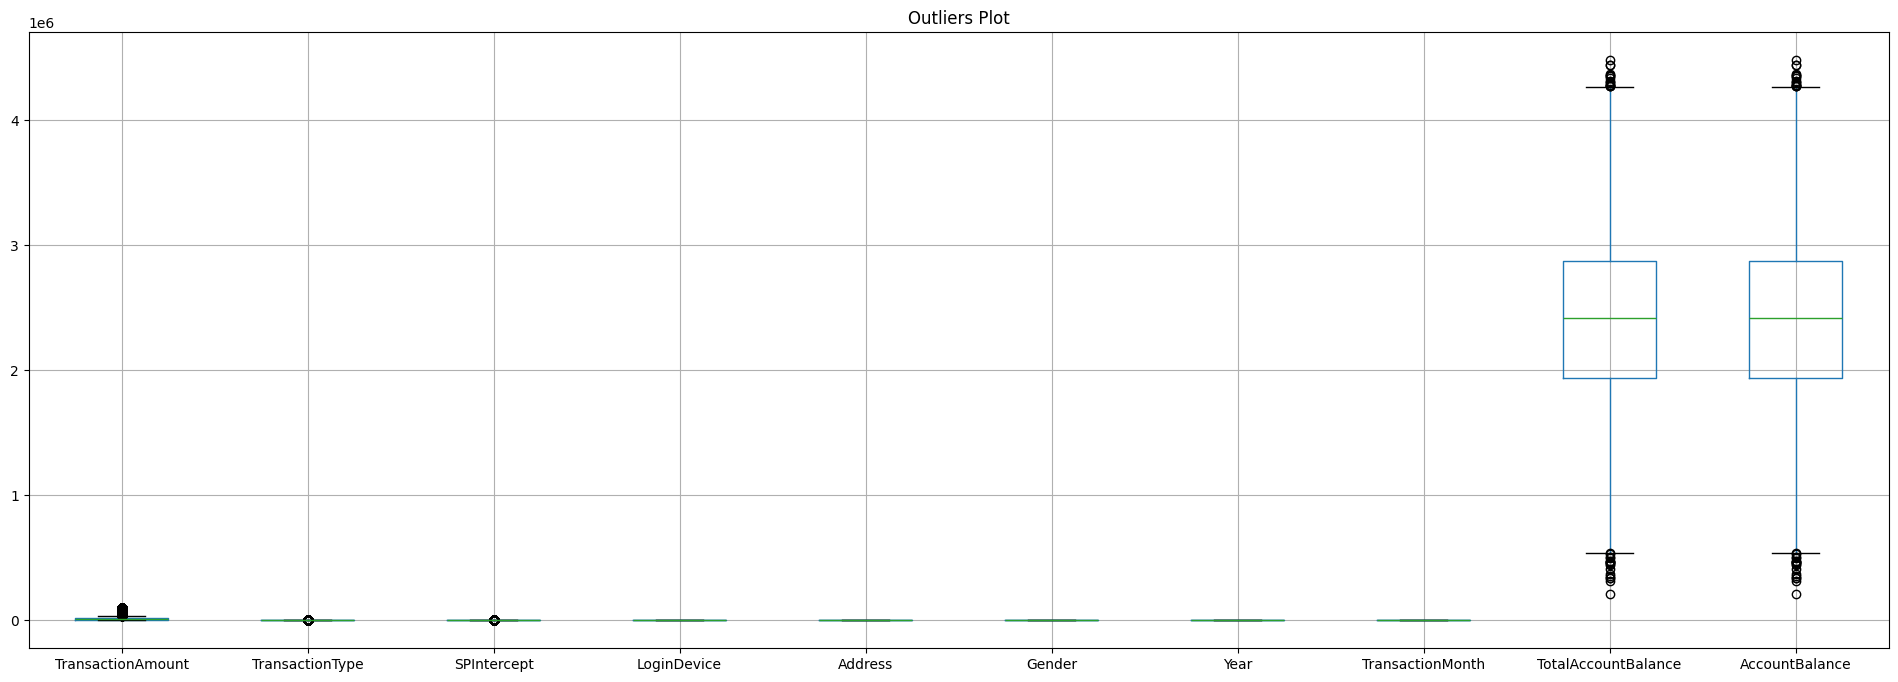

In [317]:
plt.figure(figsize=(24,8))
plt.title("Outliers Plot")
merged_df.boxplot()

In [318]:
#IQR method

Q1 = merged_df.quantile(0.25)
Q3 = merged_df.quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
filtered_df = merged_df[~((merged_df < lower_bound) | (merged_df > upper_bound)).any(axis=1)]


<Axes: title={'center': 'Outliers Plot'}>

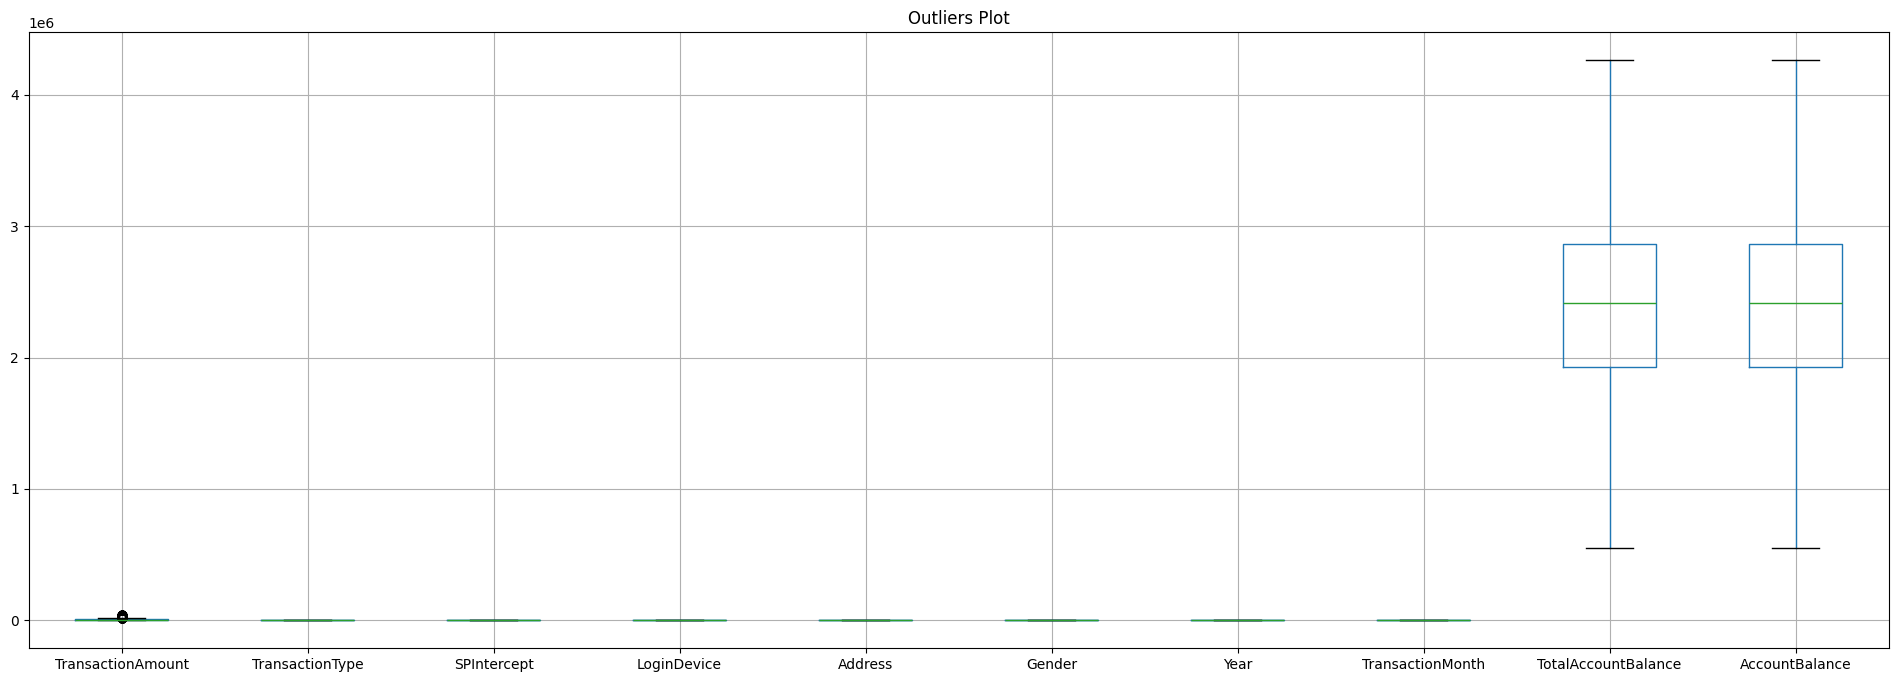

In [319]:
plt.figure(figsize=(24,8))
plt.title("Outliers Plot")
filtered_df.boxplot()

In [320]:
# Get unique values for the entire DataFrame
unique_values_per_row = merged_df.apply(lambda x: x.unique())
unique_values_per_row

TransactionAmount      [8790.43, 88410.38, 8516.21, 867.57, 88625.2, ...
TransactionType        [0.376448081623977, 0.38144329896907214, 0.242...
SPIntercept                                                       [0, 1]
LoginDevice            [0.2441279625890105, 0.2423211818471676, 0.259...
Address                                                            [1.0]
Gender                                                            [0, 1]
Year                   [1972, 2014, 1959, 1940, 1967, 1989, 1932, 197...
TransactionMonth                 [11, 7, 6, 8, 3, 2, 12, 4, 10, 5, 1, 9]
TotalAccountBalance    [2424448.09, 2684403.4, 1472198.35, 2559678.96...
AccountBalance         [2424448.09, 2684403.4, 1472198.35, 2559678.96...
dtype: object

In [321]:
# #Robust Scaling

# from sklearn.preprocessing import RobustScaler

# scaler = RobustScaler()

# # Select the features you want to scale
# features_to_scale = ['TotalAccountBalance', 'AccountBalance','Year','TransactionAmount']

# # Fit and transform the selected features
# merged_df[features_to_scale] = scaler.fit_transform(merged_df[features_to_scale])

<Axes: title={'center': 'Outliers Plot'}>

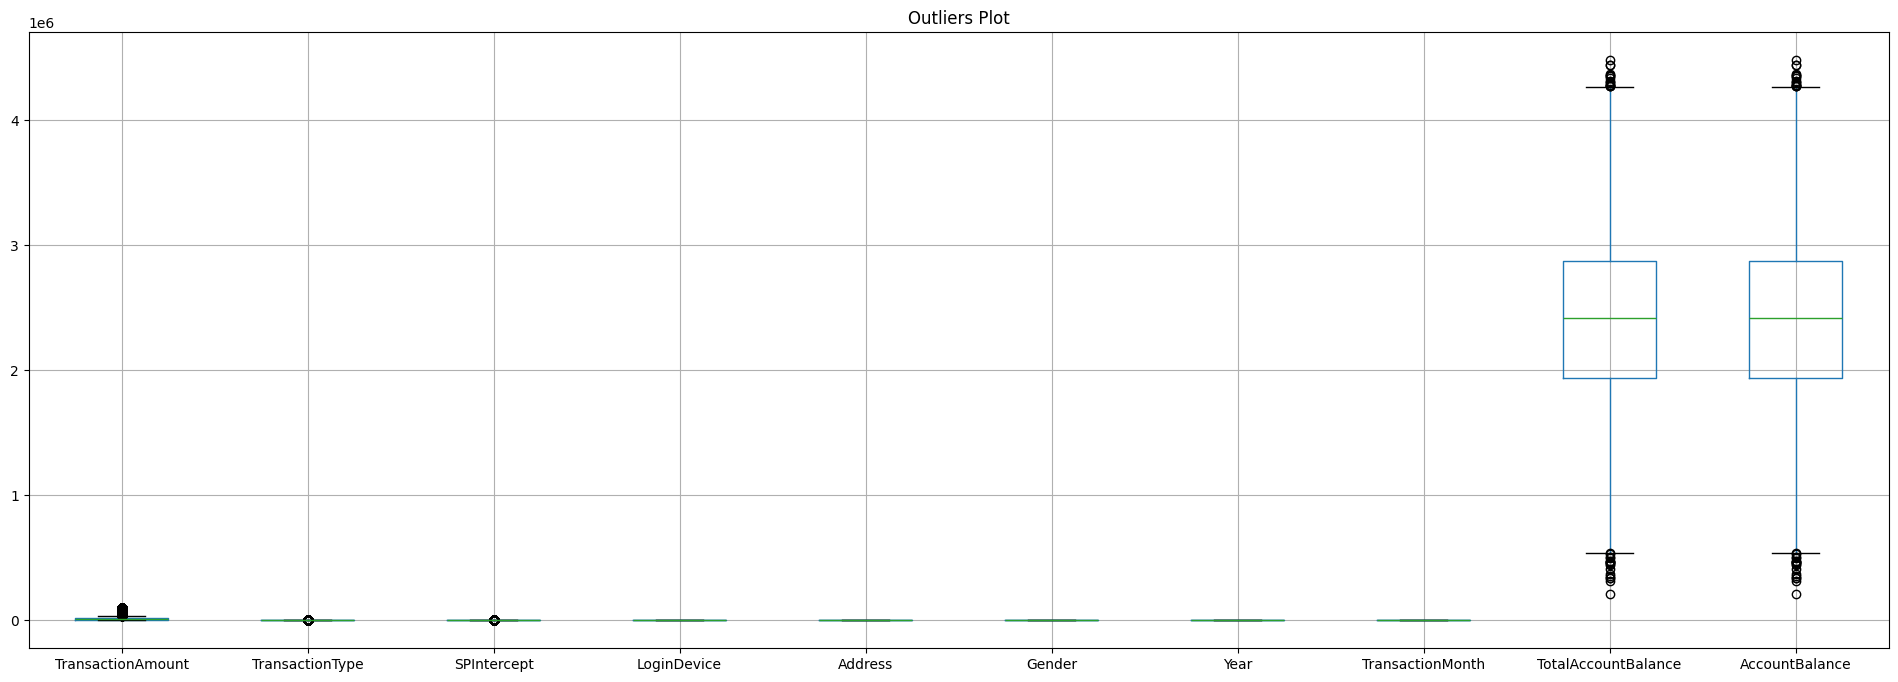

In [322]:
plt.figure(figsize=(24,8))
plt.title("Outliers Plot")
merged_df.boxplot()

## Feature Selection

In [323]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler


# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(filtered_df.select_dtypes(include=[np.number]))

# Apply Variance Threshold
var_thresh = VarianceThreshold(threshold=0.1)
X_var_thresh = var_thresh.fit_transform(X_scaled)

# Get the selected feature indices
selected_indices_var_thresh = var_thresh.get_support(indices=True)
selected_features_var_thresh = filtered_df.columns[selected_indices_var_thresh]
print(f"Selected features: {list(selected_features_var_thresh)}")



Selected features: ['TransactionAmount', 'TransactionType', 'LoginDevice', 'Gender', 'Year', 'TransactionMonth', 'TotalAccountBalance', 'AccountBalance']


In [324]:
# new dataset with only the important features

filtered2_df=merged_df[['TransactionMonth', 'TransactionType', 'SPIntercept', 'Address', 'Gender', 'TransactionMonth']]
filtered2_df

,TransactionMonth,TransactionType,SPIntercept,Address,Gender,TransactionMonth
0,11,0.376448,0,1.0,0,11
1,7,0.381443,0,1.0,0,7
2,6,0.242109,1,1.0,1,6
3,11,0.376448,0,1.0,1,11
4,7,0.376448,0,1.0,0,7
...,...,...,...,...,...,...
9404,11,0.376448,0,1.0,1,11
9405,3,0.381443,1,1.0,1,3
9406,7,0.376448,0,1.0,1,7
9407,6,0.242109,0,1.0,0,6


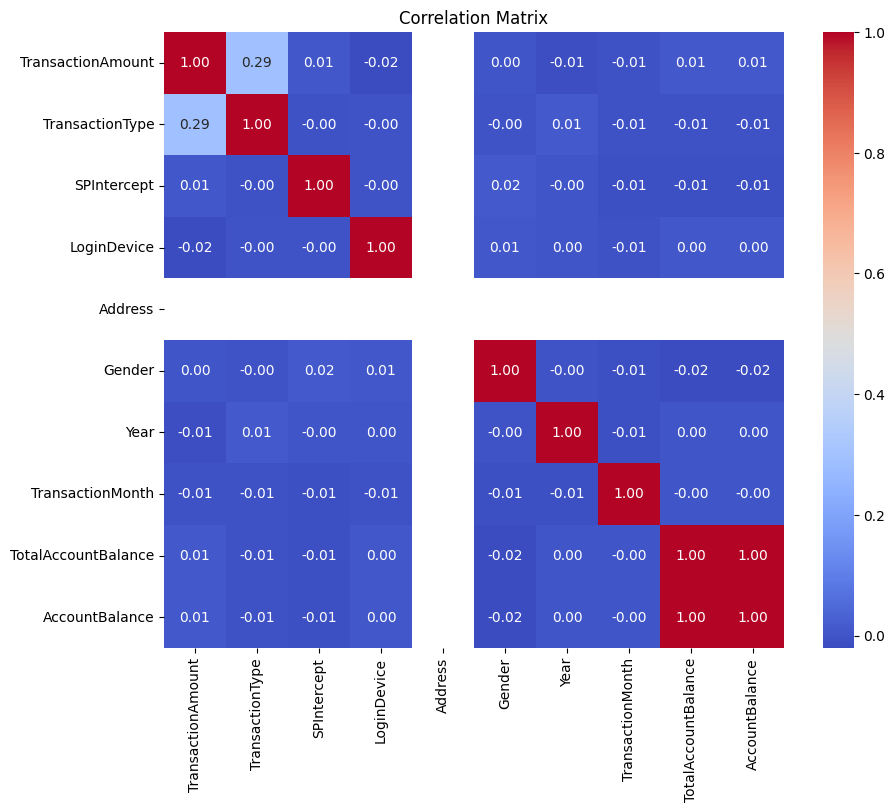

In [325]:
# Compute correlation matrix
corr_matrix = merged_df.corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Remove highly correlated features (e.g., above 0.7 correlation)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column].abs() > 0.7)]

# Drop selected features
filtered2_df = merged_df.drop(columns=to_drop)

The address cells is empty due to its high coorelation as they are fake addresses with not very distinct values, so according to our analysis 

## Training the model

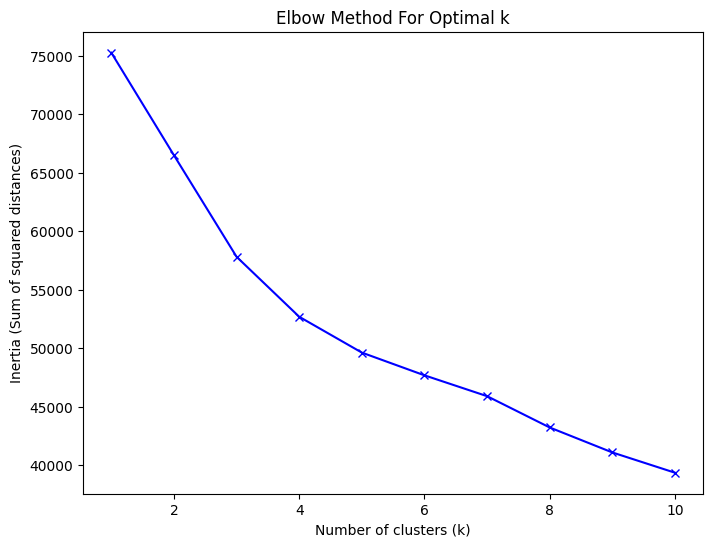

In [326]:
# Elbow Method to determine the optimum number of Clusters (k)

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


scaler = StandardScaler()
X_scaled = scaler.fit_transform(filtered2_df.select_dtypes(include=[np.number]))

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Sum of squared distances)')
plt.title('Elbow Method For Optimal k')
plt.show()


In [327]:
# Sample data 
X = filtered2_df

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize KMeans
kmeans = KMeans(n_clusters=4, random_state=42)  # Adjust n_clusters based on your use case

# Fit the model
kmeans.fit(X_scaled)

# Predict the cluster labels
cluster_labels = kmeans.predict(X_scaled)


# Calculate the silhouette score
silhouette_avg = silhouette_score(X_scaled, cluster_labels)

print(f"The average silhouette score is: {silhouette_avg}")
# Naming clusters 
cluster_names = {0: 'Platinum', 1: 'Gold', 2: 'Silver', 3: 'Bronze'}

# Map the cluster labels to the cluster names
named_clusters = np.vectorize(cluster_names.get)(cluster_labels)

# Add the named clusters to your DataFrame
filtered2_df['Cluster'] = named_clusters

# To view the resulting named clusters
filtered2_df.head()



The average silhouette score is: 0.1474557901099864


,TransactionAmount,TransactionType,SPIntercept,LoginDevice,Address,Gender,Year,TransactionMonth,TotalAccountBalance,Cluster
0,8790.43,0.376448,0,0.244128,1.0,0,1972,11,2424448.09,Bronze
1,88410.38,0.381443,0,0.244128,1.0,0,2014,7,2684403.40,Platinum
2,8516.21,0.242109,1,0.242321,1.0,1,1959,6,1472198.35,Silver
3,867.57,0.376448,0,0.244128,1.0,1,1940,11,2559678.96,Bronze
4,88625.20,0.376448,0,0.259220,1.0,0,1967,7,1987534.38,Platinum


In [328]:
# Ensure you are only working with numerical columns
numeric_df = filtered2_df.select_dtypes(include=[np.number])

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

# Apply PCA to reduce dimensions
pca = PCA(n_components=2)  # Adjust as needed
X_pca = pca.fit_transform(X_scaled)

# Initialize KMeans
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit the model
kmeans.fit(X_pca)

# Predict the cluster labels
cluster_labels = kmeans.predict(X_pca)

# Calculate the silhouette score
silhouette_avg = silhouette_score(X_pca, cluster_labels)
print(f"The average silhouette score after PCA is: {silhouette_avg}")

# Naming clusters
cluster_names = {0: 'Platinum', 1: 'Gold', 2: 'Silver'}

# Map the cluster labels to the cluster names
named_clusters = np.vectorize(cluster_names.get)(cluster_labels)

# Add the named clusters to your original DataFrame
Final_df=filtered2_df
Final_df['Cluster'] = named_clusters

# To view the resulting named clusters
filtered2_df.head()


The average silhouette score after PCA is: 0.3632358003849705


,TransactionAmount,TransactionType,SPIntercept,LoginDevice,Address,Gender,Year,TransactionMonth,TotalAccountBalance,Cluster
0,8790.43,0.376448,0,0.244128,1.0,0,1972,11,2424448.09,Gold
1,88410.38,0.381443,0,0.244128,1.0,0,2014,7,2684403.40,Platinum
2,8516.21,0.242109,1,0.242321,1.0,1,1959,6,1472198.35,Silver
3,867.57,0.376448,0,0.244128,1.0,1,1940,11,2559678.96,Gold
4,88625.20,0.376448,0,0.259220,1.0,0,1967,7,1987534.38,Platinum


The average silhouette score for the Gaussian Mixture Model is: 0.16509141026385513


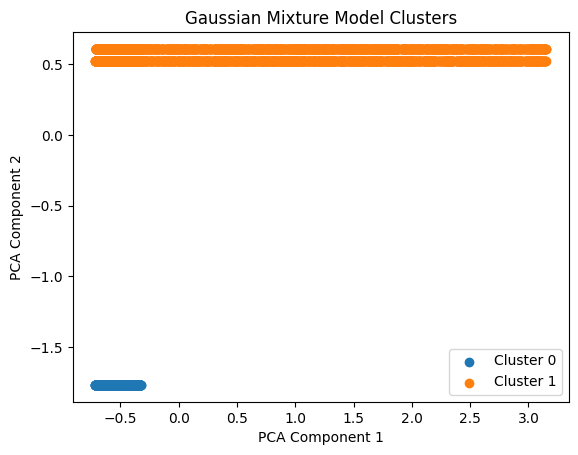

In [329]:
from numpy import unique, where
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

# Only numeric values
numeric_df = filtered2_df.select_dtypes(include=[np.number])

# Standardize the features (if necessary)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

# Define the Gaussian Mixture Model
gaussian_model = GaussianMixture(n_components=2)  # Adjust n_components as needed

# Train the model
gaussian_model.fit(X_scaled)

# Assign each data point to a cluster
gaussian_result = gaussian_model.predict(X_scaled)

# Calculate the silhouette score
silhouette_avg = silhouette_score(X_scaled, gaussian_result)
print(f"The average silhouette score for the Gaussian Mixture Model is: {silhouette_avg}")

# Get all of the unique clusters
gaussian_clusters = unique(gaussian_result)

# Plot the Gaussian Mixture clusters
for gaussian_cluster in gaussian_clusters:
    # Get data points that fall in this cluster
    index = where(gaussian_result == gaussian_cluster)
    # Make the plot
    plt.scatter(X_scaled[index, 0], X_scaled[index, 1], label=f'Cluster {gaussian_cluster}')

# Add labels and show the plot
plt.title("Gaussian Mixture Model Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()


Final Dataset


In [330]:
last_column = Final_df.iloc[:, -1]
Last_df['Tiers'] = last_column.values

Last_df.head(20)

,CustomerID,AccountNumber,TransactionAmount,TransactionType,SPIntercept,SPTimestamp,LoginDevice,TransactionDevice,LoginTimestamp,CustomerName,Email,PhoneNumber,Address,Gender,Year,TransactionMonth,TotalAccountBalance,AccountBalance,Tiers
0,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB30SPXD57546556446883,8790.43,Online Payment,0,2020-11-02 02:59:33,Laptop,Laptop,2020-11-02 02:59:30,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,11,2424448.09,2424448.09,Gold
1,112d81e0-caca-4ba3-b6ad-c31178438dac,GB36JIUK97271708985004,88410.38,Money Transfer,0,2020-07-14 16:20:19,Laptop,Laptop,2020-07-14 16:20:13,Emily Rodriguez,allison37@example.com,8103991750,"766 Smith Pines\nMatthewland, GU 69433",Male,2014,7,2684403.40,2684403.40,Platinum
2,ec75eb51-73ea-40a9-b865-872adf4cc66e,GB10KXRB50555098796496,8516.21,ATM Withdrawal,1,2023-06-02 07:02:50,Tablet,Laptop,2023-06-02 07:01:12,Valerie Erickson,deleonmary@example.net,001-518-215-9510x63655,"064 Miller Canyon\nNew Nicole, MS 14275",Female,1959,6,1472198.35,1472198.35,Silver
3,8b8ddb5d-2b0a-434c-a25d-b4408dffb66c,GB39WZUC09937561862131,867.57,Online Payment,0,2020-11-23 18:27:02,Laptop,Laptop,2020-11-23 18:26:45,Paige Riggs,courtney78@example.net,640-816-6789,USNS Ross\nFPO AA 94265,Female,1940,11,2559678.96,2559678.96,Gold
4,009cbfcb-ee30-40fd-88ac-eab5e3e6ff62,GB75OOYJ73027493458122,88625.20,Online Payment,0,2022-07-30 00:46:13,Mobile,Mobile,2022-07-30 00:46:00,Devon Wright,camachodaniel@example.com,001-402-236-4082x438,"799 William Stream Apt. 755\nGarnertown, MS 89065",Male,1967,7,1987534.38,1987534.38,Platinum
5,5da583b8-d009-49c1-bc2b-9f4893110344,GB98EWSX67538711447297,19688.72,Money Transfer,0,2023-08-19 21:29:47,Laptop,Laptop,2023-08-19 21:29:44,Stuart King,qrivera@example.net,343-253-3093x97577,"62727 Mendoza Streets\nGonzalezview, VA 54616",Female,1989,8,812375.56,812375.56,Silver
6,4bfbd404-ce07-4f09-998d-cb87eba15982,GB53GKGG46080707066988,3125.74,Online Payment,0,2020-03-02 07:52:32,Tablet,Tablet,2020-03-02 07:52:31,Todd Murphy,markjones@example.org,+1-663-863-5575x97198,"8783 Lozano Corner\nAndersonhaven, VI 38957",Female,1932,3,3688880.17,3688880.17,Gold
7,140d5f4a-cf8e-4d06-ad41-af9ca24eabc4,GB31ARMI65314300184428,54870.00,Online Payment,0,2023-06-10 21:41:00,Tablet,Tablet,2023-06-10 21:40:42,Angela Vega,susan79@example.net,833-470-1664x722,"02950 Andrew Field Apt. 338\nEdwardport, NJ 70562",Female,1970,6,3210776.76,3210776.76,Platinum
8,158d76dd-c902-4885-abe8-d53772d883be,GB11LDXH98439758258777,9497.57,Money Transfer,0,2021-02-03 07:14:38,Tablet,Tablet,2021-02-03 07:14:23,Charlene Mccoy,roberthanson@example.net,(261)490-7270x731,"074 Anthony Centers\nTuckerland, AL 22242",Female,1969,2,2796594.64,2796594.64,Silver
9,65eb3689-37af-4fec-b0c7-93a6ccf2bfe9,GB98VFJB22133381678020,11623.97,Online Payment,0,2020-12-27 15:10:52,Laptop,Laptop,2020-12-27 15:10:38,Michael Taylor,johnlove@example.net,365-243-0862,"PSC 4438, Box 1896\nAPO AA 40063",Female,1946,12,2890421.98,2890421.98,Gold


In [331]:
Last_df = Last_df.drop(columns=['AccountBalance'])

# Display the DataFrame to confirm the column has been dropped
Last_df.head()



,CustomerID,AccountNumber,TransactionAmount,TransactionType,SPIntercept,SPTimestamp,LoginDevice,TransactionDevice,LoginTimestamp,CustomerName,Email,PhoneNumber,Address,Gender,Year,TransactionMonth,TotalAccountBalance,Tiers
0,e0497be9-6494-4efb-b575-fe9f55fccfe4,GB30SPXD57546556446883,8790.43,Online Payment,0,2020-11-02 02:59:33,Laptop,Laptop,2020-11-02 02:59:30,Sara Chen,aguirrealison@example.com,422-973-7577x76091,"8664 Butler Ramp\nEast Scott, OK 87220",Male,1972,11,2424448.09,Gold
1,112d81e0-caca-4ba3-b6ad-c31178438dac,GB36JIUK97271708985004,88410.38,Money Transfer,0,2020-07-14 16:20:19,Laptop,Laptop,2020-07-14 16:20:13,Emily Rodriguez,allison37@example.com,8103991750,"766 Smith Pines\nMatthewland, GU 69433",Male,2014,7,2684403.40,Platinum
2,ec75eb51-73ea-40a9-b865-872adf4cc66e,GB10KXRB50555098796496,8516.21,ATM Withdrawal,1,2023-06-02 07:02:50,Tablet,Laptop,2023-06-02 07:01:12,Valerie Erickson,deleonmary@example.net,001-518-215-9510x63655,"064 Miller Canyon\nNew Nicole, MS 14275",Female,1959,6,1472198.35,Silver
3,8b8ddb5d-2b0a-434c-a25d-b4408dffb66c,GB39WZUC09937561862131,867.57,Online Payment,0,2020-11-23 18:27:02,Laptop,Laptop,2020-11-23 18:26:45,Paige Riggs,courtney78@example.net,640-816-6789,USNS Ross\nFPO AA 94265,Female,1940,11,2559678.96,Gold
4,009cbfcb-ee30-40fd-88ac-eab5e3e6ff62,GB75OOYJ73027493458122,88625.20,Online Payment,0,2022-07-30 00:46:13,Mobile,Mobile,2022-07-30 00:46:00,Devon Wright,camachodaniel@example.com,001-402-236-4082x438,"799 William Stream Apt. 755\nGarnertown, MS 89065",Male,1967,7,1987534.38,Platinum


In [332]:
# from collections import Counter

# # Group by 'CustomerName' and find the most common tier
# def most_common_tier(group):
#     # Count the occurrences of each tier for this customer
#     tier_counts = Counter(group['Tiers'])
    
#     # Return the tier with the maximum count (most common)
#     return tier_counts.most_common(1)[0][0]

# common_tiers = Last_df.groupby('CustomerName').apply(most_common_tier).reset_index()

# common_tiers.columns = ['CustomerName', 'MostCommonTier']

# Last_df = pd.merge(Last_df, common_tiers, on='CustomerName', how='left')
# Last_df['Tiers'] = Last_df['MostCommonTier']


# Last_df = Last_df.drop(columns=['MostCommonTier'])

# Last_df.head(20)
